# KIQ 3.2 — Sentiment on Meta's Name Tag facial recognition feature

**Question:** What is the public sentiment on Meta's Name Tag (facial-recognition) feature on Reddit?

**Pipeline:** for every KIQ_3_2 post and comment, ask the local LLM (`gemma4-q6` via Ollama)
to (a) judge whether the item is *substantively* about Name Tag / facial recognition and
(b) score sentiment toward that topic. Items the model marks as not-relevant are dropped.

**Caveats**
- Sample is small after relevance filtering. Cite direction + supporting quotes, not precise %.
- LLM judgements are deterministic at temperature 0 but are not gold labels.
  Spot-check `outputs/kiq_3_2/kiq_3_2_dropped_*.csv` to verify the filter is sensible.

## Setup

In [2]:
import sys
from pathlib import Path

# Allow `import analysis_utils` and `import llm_utils` from notebooks/.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from analysis_utils import (
    BRAND_KEYWORDS,
    detect_brands,
    explode_brands,
    has_any_brand,
    sentiment_distribution,
    weekly_volume_and_sentiment,
    monthly_volume_and_sentiment,
)
from llm_utils import (
    score_dataframe_with_cache,
    smoke_test,
    DEFAULT_MODEL,
    KIQ_TOPICS,
)

POSTS_PATH = ROOT / "data" / "processed" / "reddit_posts_clean.csv"
COMMENTS_PATH = ROOT / "data" / "processed" / "reddit_comments_clean.csv"
CACHE_DIR = ROOT / "data" / "llm_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)


In [3]:
OUT_DIR = ROOT / 'outputs' / 'kiq_3_2'
OUT_DIR.mkdir(parents=True, exist_ok=True)
KIQ = 'KIQ_3_2'

## Load and filter by KIQ label

In [4]:
posts = pd.read_csv(POSTS_PATH)
comments = pd.read_csv(COMMENTS_PATH)

# Build the text we send to the LLM. Use the original (pre-cleanup) title + body where available;
# the cleaned text strips punctuation and case which hurts LLM comprehension.
posts['_llm_text'] = (
    posts['title'].fillna('').astype(str) + ' ' + posts['text'].fillna('').astype(str)
).str.strip()
comments['_llm_text'] = comments['body'].fillna('').astype(str)

posts_k = posts[(posts['kiq_label'] == KIQ) & (posts['_llm_text'].str.len() > 0)].copy()
comments_k = comments[(comments['kiq_label'] == KIQ) & (comments['_llm_text'].str.len() > 0)].copy()

print(f'Posts (KIQ_3_2):    {len(posts_k):>5}')
print(f'Comments (KIQ_3_2): {len(comments_k):>5}')
print(f'Estimated first-run LLM time at 4s/call: ~{(len(posts_k)+len(comments_k))*4/60:.0f} minutes')

Posts (KIQ_3_2):       56
Comments (KIQ_3_2):   849
Estimated first-run LLM time at 4s/call: ~60 minutes


## LLM scoring (relevance + sentiment)

Each post and comment is sent to Ollama (`gemma4-q6:latest`, `think=false`).
The model returns `is_relevant`, `sentiment_label`, `sentiment_score`, and a brief `reason`.
Results are cached to `data/llm_cache/` by item id, so re-running this cell is instant after the first pass.

In [18]:
# Pre-flight: confirm Ollama + model are reachable BEFORE we start a long run.
import time
t0 = time.time()
_check = smoke_test()
print(f"Ollama OK ({DEFAULT_MODEL}) — single-call latency: {time.time()-t0:.1f}s")
print(f"  sample result: {_check}")


Ollama OK (gemma4-q6:latest) — single-call latency: 3.5s
  sample result: {'is_relevant': True, 'sentiment_label': 'negative', 'sentiment_score': -0.8, 'reason': "The comment directly discusses Meta's facial recognition feature and expresses strong negative concerns about privacy."}


In [19]:
posts_scored = score_dataframe_with_cache(
    posts_k,
    text_col='_llm_text',
    id_col='post_id',
    cache_path=CACHE_DIR / 'kiq_3_2_posts.csv',
    kiq='KIQ_3_2',
    kind='post',
)
comments_scored = score_dataframe_with_cache(
    comments_k,
    text_col='_llm_text',
    id_col='comment_id',
    cache_path=CACHE_DIR / 'kiq_3_2_comments.csv',
    kiq='KIQ_3_2',
    kind='comment',
)
posts_scored[['post_id', 'subreddit', 'is_relevant', 'sentiment_label', 'sentiment_score']].head()

[KIQ_3_2/post] cached: 56, to score: 0 of 56


KIQ_3_2/post: 0it [00:00, ?it/s]


[KIQ_3_2/comment] cached: 849, to score: 0 of 849


KIQ_3_2/comment: 0it [00:00, ?it/s]


,post_id,subreddit,is_relevant,sentiment_label,sentiment_score
0,1rknu5q,augmentedreality,True,negative,-0.7
1,1rl91kl,technology,True,negative,-0.8
2,1sw8hk3,apple,False,neutral,0.0
3,1r3s14v,technology,True,negative,-0.7
4,1rljafg,technology,True,negative,-0.7


## Apply LLM relevance filter

Drop items the model judged off-topic. The dropped sets are written to
`outputs/kiq_3_2/kiq_3_2_dropped_*.csv` for spot-checking.

In [20]:
posts_before = len(posts_scored); comments_before = len(comments_scored)
posts_dropped = posts_scored[posts_scored['is_relevant'] == False].copy()
comments_dropped = comments_scored[comments_scored['is_relevant'] == False].copy()
posts_scored = posts_scored[posts_scored['is_relevant'] == True].copy()
comments_scored = comments_scored[comments_scored['is_relevant'] == True].copy()

filter_log = pd.DataFrame([
    {'slice': 'posts',    'n_before': posts_before,    'n_after': len(posts_scored)},
    {'slice': 'comments', 'n_before': comments_before, 'n_after': len(comments_scored)},
])
print(f'Posts:    {posts_before:>5} -> {len(posts_scored):>5} after LLM relevance filter')
print(f'Comments: {comments_before:>5} -> {len(comments_scored):>5} after LLM relevance filter')
filter_log

Posts:       56 ->    21 after LLM relevance filter
Comments:   849 ->   125 after LLM relevance filter


,slice,n_before,n_after
0,posts,56,21
1,comments,849,125


## Sentiment label distribution

In [21]:
dist_posts = sentiment_distribution(posts_scored)
dist_comments = sentiment_distribution(comments_scored)
dist_combined = sentiment_distribution(
    pd.concat([posts_scored[['sentiment_label']], comments_scored[['sentiment_label']]],
              ignore_index=True)
)
dist_df = pd.DataFrame({'posts': dist_posts, 'comments': dist_comments, 'combined': dist_combined})
dist_pct = (dist_df / dist_df.sum()) * 100
dist_pct.round(1)

,posts,comments,combined
sentiment_label,,,
positive,0.0,4.8,4.1
neutral,0.0,16.0,13.7
negative,100.0,79.2,82.2


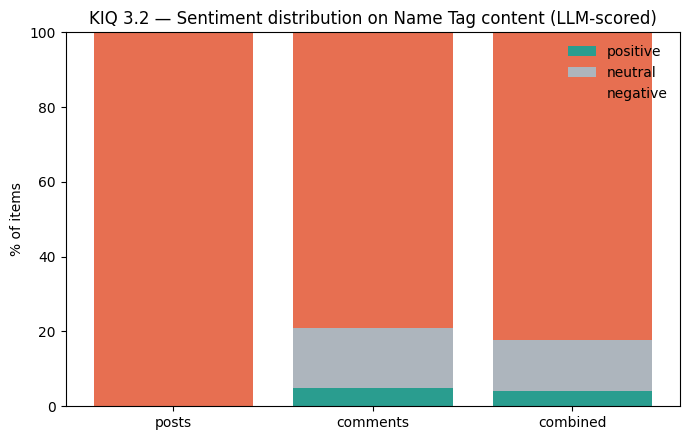

In [22]:
fig, ax = plt.subplots(figsize=(7, 4.5), dpi=100)
colors = {'positive': '#2a9d8f', 'neutral': '#adb5bd', 'negative': '#e76f51'}
x = list(range(len(dist_pct.columns)))
bottom = [0] * len(dist_pct.columns)
for label in ['positive', 'neutral', 'negative']:
    vals = dist_pct.loc[label].values
    ax.bar(x, vals, bottom=bottom, label=label, color=colors[label])
    bottom = [b + v for b, v in zip(bottom, vals)]
ax.set_xticks(x); ax.set_xticklabels(dist_pct.columns)
ax.set_ylim(0, 100); ax.set_ylabel('% of items')
ax.set_title(f'KIQ 3.2 — Sentiment distribution on Name Tag content (LLM-scored)')
ax.legend(loc='upper right', frameon=False)
fig.tight_layout()
fig.savefig(OUT_DIR / 'kiq_3_2_distribution.png', dpi=300)
plt.show()

## Mean sentiment score by subreddit

In [23]:
combined = pd.concat([
    posts_scored[['subreddit', 'sentiment_score']].assign(_kind='post'),
    comments_scored[['subreddit', 'sentiment_score']].assign(_kind='comment'),
], ignore_index=True)
by_sub = combined.groupby('subreddit').agg(
    n=('sentiment_score', 'size'),
    mean_score=('sentiment_score', 'mean'),
)
by_sub = by_sub[by_sub['n'] >= 3].sort_values('mean_score')
by_sub

,n,mean_score
subreddit,,
privacy,39,-0.600000
augmentedreality,38,-0.528947
technology,54,-0.527778
RaybanMeta,6,-0.516667
SmartGlasses,6,-0.450000


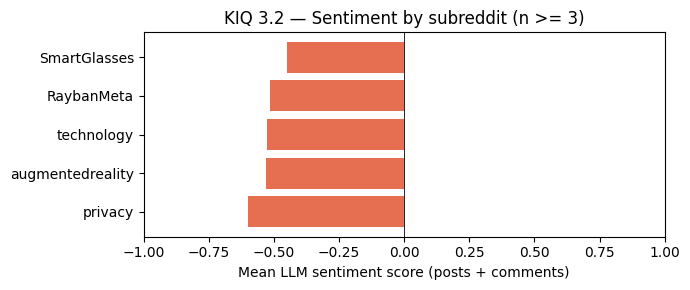

In [24]:
if not by_sub.empty:
    fig, ax = plt.subplots(figsize=(7, max(3, 0.35 * len(by_sub))), dpi=100)
    colors_bar = ['#e76f51' if v < 0 else '#2a9d8f' for v in by_sub['mean_score']]
    ax.barh(by_sub.index, by_sub['mean_score'], color=colors_bar)
    ax.axvline(0, color='black', lw=0.6)
    ax.set_xlim(-1, 1)
    ax.set_xlabel('Mean LLM sentiment score (posts + comments)')
    ax.set_title('KIQ 3.2 — Sentiment by subreddit (n >= 3)')
    fig.tight_layout()
    fig.savefig(OUT_DIR / 'kiq_3_2_by_subreddit.png', dpi=300)
    plt.show()
else:
    print('No subreddit reached the n>=3 threshold; skipping chart.')

## Monthly trend

In [25]:
monthly_posts = monthly_volume_and_sentiment(posts_scored)
monthly_comments = monthly_volume_and_sentiment(comments_scored)
monthly_comments.head()

,month,n,mean_score,share_pos,share_neg
0,2025-02,1,-0.7000,0.0,1.000
1,2025-08,3,-0.7000,0.0,1.000
2,2025-09,8,-0.4375,0.0,0.625
3,2025-10,1,-0.8000,0.0,1.000
4,2025-11,2,-0.6000,0.0,1.000


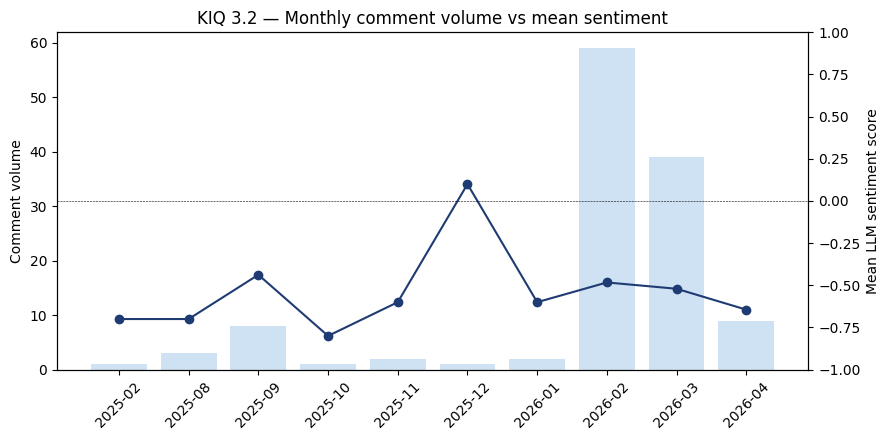

In [26]:
fig, ax1 = plt.subplots(figsize=(9, 4.5), dpi=100)
if not monthly_comments.empty:
    ax1.bar(monthly_comments['month'], monthly_comments['n'],
            color='#cfe2f3', label='comments / month')
ax1.set_ylabel('Comment volume')
ax1.tick_params(axis='x', rotation=45)
ax2 = ax1.twinx()
if not monthly_comments.empty:
    ax2.plot(monthly_comments['month'], monthly_comments['mean_score'],
             color='#1f3b73', marker='o', label='mean sentiment (comments)')
ax2.axhline(0, color='black', lw=0.4, linestyle='--')
ax2.set_ylim(-1, 1)
ax2.set_ylabel('Mean LLM sentiment score')
ax1.set_title('KIQ 3.2 — Monthly comment volume vs mean sentiment')
fig.tight_layout()
fig.savefig(OUT_DIR / 'kiq_3_2_monthly.png', dpi=300)
plt.show()

## Top representative quotes

In [27]:
def top_quotes(df, text_col, kind, n=5):
    if df.empty:
        return pd.DataFrame()
    cols = ['sentiment_score', 'sentiment_label', 'reason', 'subreddit', 'created_utc', text_col]
    pos = df.nlargest(n, 'sentiment_score')[cols].assign(kind=kind, polarity='positive')
    neg = df.nsmallest(n, 'sentiment_score')[cols].assign(kind=kind, polarity='negative')
    out = pd.concat([pos, neg], ignore_index=True)
    return out.rename(columns={text_col: 'text'})

top = pd.concat([
    top_quotes(posts_scored, '_llm_text', 'post'),
    top_quotes(comments_scored, '_llm_text', 'comment'),
], ignore_index=True)
top['text'] = top['text'].astype(str).str.slice(0, 280)
top

,sentiment_score,sentiment_label,reason,subreddit,created_utc,text,kind,polarity
0,-0.6,negative,The title expresses worry about privacy and th...,augmentedreality,2026-03-16,Meta Explained Its Smart Glasses AI Privacy Po...,post,positive
1,-0.7,negative,The post critiques the cycle of fear surroundi...,augmentedreality,2026-03-04,"I built one of Glass's first apps, here's what...",post,positive
2,-0.7,negative,The title directly addresses Meta's plan for f...,technology,2026-02-13,Meta reportedly wants to add face recognition ...,post,positive
3,-0.7,negative,The title focuses on privacy alarms regarding ...,technology,2026-03-05,Meta's smart glasses raise privacy alarms as d...,post,positive
4,-0.7,negative,The title directly addresses Meta's plan for f...,privacy,2026-02-13,Meta reportedly wants to add face recognition ...,post,positive
5,-0.9,negative,The post directly criticizes Meta's glasses fo...,privacy,2026-03-07,What privacy? Meta's smart glasses are filming...,post,negative
6,-0.8,negative,The post discusses facial recognition implemen...,technology,2026-03-05,Meta's Ray-Ban glasses route your bedroom foot...,post,negative
7,-0.8,negative,The title explicitly frames the smart glasses ...,privacy,2025-07-27,Title: Meta Smart Glasses Are a Privacy Disast...,post,negative
8,-0.8,negative,Strongly negative sentiment regarding facial r...,privacy,2025-08-20,Google glasses v3 or another group of tech Bro...,post,negative
9,-0.8,negative,The post discusses Meta's facial recognition c...,privacy,2025-09-14,Harvard students proved Meta smart glasses can...,post,negative


## Write outputs

In [28]:
summary = pd.DataFrame([
    {'slice': 'posts', 'n': len(posts_scored),
     'pct_positive': (posts_scored['sentiment_label'] == 'positive').mean() * 100,
     'pct_neutral':  (posts_scored['sentiment_label'] == 'neutral').mean() * 100,
     'pct_negative': (posts_scored['sentiment_label'] == 'negative').mean() * 100,
     'mean_score':   posts_scored['sentiment_score'].mean()},
    {'slice': 'comments', 'n': len(comments_scored),
     'pct_positive': (comments_scored['sentiment_label'] == 'positive').mean() * 100,
     'pct_neutral':  (comments_scored['sentiment_label'] == 'neutral').mean() * 100,
     'pct_negative': (comments_scored['sentiment_label'] == 'negative').mean() * 100,
     'mean_score':   comments_scored['sentiment_score'].mean()},
])

posts_scored.to_csv(OUT_DIR / 'kiq_3_2_scored_posts.csv', index=False)
comments_scored.to_csv(OUT_DIR / 'kiq_3_2_scored_comments.csv', index=False)
summary.to_csv(OUT_DIR / 'kiq_3_2_summary.csv', index=False)
top.to_csv(OUT_DIR / 'kiq_3_2_top_quotes.csv', index=False)
filter_log.to_csv(OUT_DIR / 'kiq_3_2_filter_log.csv', index=False)
posts_dropped.to_csv(OUT_DIR / 'kiq_3_2_dropped_posts.csv', index=False)
comments_dropped.to_csv(OUT_DIR / 'kiq_3_2_dropped_comments.csv', index=False)
if not by_sub.empty:
    by_sub.reset_index().to_csv(OUT_DIR / 'kiq_3_2_by_subreddit.csv', index=False)

print('Wrote outputs to', OUT_DIR)
for f in sorted(OUT_DIR.iterdir()):
    print(' -', f.name)
summary.round(2)

Wrote outputs to /home/giulio/Uni/Master/SCI/outputs/kiq_3_2
 - kiq_3_2_by_subreddit.csv
 - kiq_3_2_by_subreddit.png
 - kiq_3_2_distribution.png
 - kiq_3_2_dropped_comments.csv
 - kiq_3_2_dropped_posts.csv
 - kiq_3_2_filter_log.csv
 - kiq_3_2_monthly.png
 - kiq_3_2_scored_comments.csv
 - kiq_3_2_scored_posts.csv
 - kiq_3_2_summary.csv
 - kiq_3_2_top_quotes.csv


,slice,n,pct_positive,pct_neutral,pct_negative,mean_score
0,posts,21,0.0,0.0,100.0,-0.75
1,comments,125,4.8,16.0,79.2,-0.51
